# Coursework: Mammographic density prediction

In this coursework, you will implement a model for breast tissue density prediction from digital screening mammography data. Mammograms are X‑ray images acquired as part of regular breast cancer screening programmes. Breast tissue density is an important risk factor and is categorised into four classes according to the BI‑RADS (Breast Imaging Reporting and Data System) standard:
- Class A – Almost entirely fatty: The breast is composed mostly of fatty tissue with minimal fibroglandular density.
- Class B – Scattered areas of fibroglandular density: There are some dense areas, but most of the tissue is still fatty.
- Class C – Heterogeneously dense: Many areas of dense tissue are present, which may obscure small masses.
- Class D – Extremely dense: The breast is composed predominantly of dense tissue, making mammographic interpretation and cancer detection more challenging.

Your task is to develop and evaluate a predictive model capable of automatically assigning these density categories from mammographic images. You will be asked to assess the performance of the model across different subgroups, and conduct a model inspection using dimensionality reduction of feature embeddings.

The coursework is divided in the following parts:

* **Part A**: Choose a sensible data augmentation pipeline within the `MammoDataset` class.
* **Part B**: Implement a sensible model for image classification within the `MammoNet` class.
* **Part C**: Conduct a subgroup performance analysis.
* **Part D**: Inspect the trained model by analysing feature embeddings.
* **Part E**: Write a short report about your coursework (using the [provided template](https://www.overleaf.com/read/rkjxjntdfdwr#df7c9e)).

**Important:** Read the text descriptions carefully and look out for hints and comments indicating a specific **TASK**. Make sure to add sufficient documentation and comments to your code.

**Submission:** You are asked to submit two files:
1. You should submit this notebook in `.ipynb` format with *all outputs included*. Please name your file `notebook.ipynb`.
2. You should also submit a short report in `.pdf` format, using [this template](https://www.overleaf.com/read/rkjxjntdfdwr#df7c9e). Please name this file `report.pdf`.

### Your details

Please add your details below. You can work in groups up to two.

Authors: **firstname1 lastname1** & **firstname2 lastname2**

DoC username: **alias1** & **alias2**

### Setup

In [1]:
# On Google Colab uncomment the following line to install additional libraries
! pip install lightning
! pip install stocaching

# See the requirements.txt file for more details on the required libraries.
# We recommend using a virtual environment to manage dependencies.
# For example, you can create a virtual environment using venv:
# python3 -m venv myenv
# source myenv/bin/activate
# pip install -r requirements.txt


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os
import cv2
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms.v2 as T
import pytorch_lightning as pl
import matplotlib.pyplot as plt
import matplotlib as mpl
import plotly.graph_objs as go
import plotly.express as px
import seaborn as sns

from matplotlib import cm
from ipywidgets import Output, HBox
from sklearn.metrics import roc_curve
from sklearn.metrics import auc
from sklearn import decomposition
from sklearn.manifold import TSNE
from skimage.io import imread
from skimage.util import img_as_ubyte
from torchmetrics.functional import auroc
from torch.utils.data import DataLoader, Dataset
from torchvision import models
from pytorch_lightning.loggers import TensorBoardLogger
from pytorch_lightning.callbacks import ModelCheckpoint, TQDMProgressBar
from stocaching import SharedCache
#from torchsampler import ImbalancedDatasetSampler

In [2]:
from typing import Callable

import pandas as pd
import torch
import torch.utils.data
import torchvision


class ImbalancedDatasetSampler(torch.utils.data.sampler.Sampler):
    """Samples elements randomly from a given list of indices for imbalanced dataset

    Arguments:
        indices: a list of indices
        num_samples: number of samples to draw
        callback_get_label: a callback-like function which takes two arguments - dataset and index
    """

    def __init__(
        self,
        dataset,
        labels: list = None,
        indices: list = None,
        num_samples: int = None,
        callback_get_label: Callable = None,
    ):
        # if indices is not provided, all elements in the dataset will be considered
        self.indices = list(range(len(dataset))) if indices is None else indices

        # define custom callback
        self.callback_get_label = callback_get_label

        # if num_samples is not provided, draw `len(indices)` samples in each iteration
        self.num_samples = len(self.indices) if num_samples is None else num_samples

        # distribution of classes in the dataset
        df = pd.DataFrame()
        df["label"] = self._get_labels(dataset) if labels is None else labels
        df.index = self.indices
        df = df.sort_index()

        label_to_count = df["label"].value_counts()

        weights = 1.0 / label_to_count[df["label"]]

        self.weights = torch.DoubleTensor(weights.to_list())

    def _get_labels(self, dataset):
        if self.callback_get_label:
            return self.callback_get_label(dataset)
        elif isinstance(dataset, torch.utils.data.TensorDataset):
            return dataset.tensors[1]
        elif isinstance(dataset, torchvision.datasets.MNIST):
            return dataset.train_labels.tolist()
        elif isinstance(dataset, torchvision.datasets.ImageFolder):
            return [x[1] for x in dataset.imgs]
        elif isinstance(dataset, torchvision.datasets.DatasetFolder):
            return dataset.samples[:][1]
        elif isinstance(dataset, torch.utils.data.Subset):
            return dataset.dataset.imgs[:][1]
        elif isinstance(dataset, torch.utils.data.Dataset):
            return dataset.get_labels()
        else:
            raise NotImplementedError

    def __iter__(self):
        return (self.indices[i] for i in torch.multinomial(self.weights, self.num_samples, replacement=True))

    def __len__(self):
        return self.num_samples

### Data

We make use of the publicly available [RSNA-SMBC dataset](https://registry.opendata.aws/rsna-screening-mammography-breast-cancer-detection/). We have preproceesed this dataset to make it easier to work with. We have reduced the image sizes to 128x96 and simplified the meta information.

Note, unzipping the dataset will take a few minutes, as there almost 30,000 images. Only needs to be done once.

In [14]:
# ! wget https://www.doc.ic.ac.uk/~bglocker/teaching/mli/rsna-small.zip
# ! unzip -q rsna-small.zip # Remove -q for verbose output

import urllib.request
import zipfile
from pathlib import Path

url = "https://www.doc.ic.ac.uk/~bglocker/teaching/mli/rsna-small.zip"
zip_path = Path("rsna-small.zip")

if not zip_path.exists():
    urllib.request.urlretrieve(url, zip_path)

if not Path("rsna-small").exists():
    with zipfile.ZipFile(zip_path, "r") as z:
        z.extractall(".")


In [3]:
DATA_DIR = './data/rsna-small'
CSV_FILE = os.path.join(DATA_DIR, 'meta.csv')
IMAGE_SIZE = (128, 96)
NUM_CLASSES = 4

Let's check the meta information of the dataset.

In [5]:
df_meta = pd.read_csv(CSV_FILE)
df_meta.head()

,image_id,laterality,view,age,cancer,implant,density,machine_id,study_id,split
0,1967300488,L,MLO,60.0,0,0,C,216,10038,training
1,2142944869,L,CC,60.0,0,0,C,216,10038,training
2,850559196,R,MLO,60.0,0,0,C,216,10038,training
3,1350492010,R,CC,60.0,0,0,C,216,10038,training
4,102733848,L,CC,51.0,0,0,C,93,10042,training


Let's visualise some random samples from each density class. You can run this cell repeatedly to see different samples.

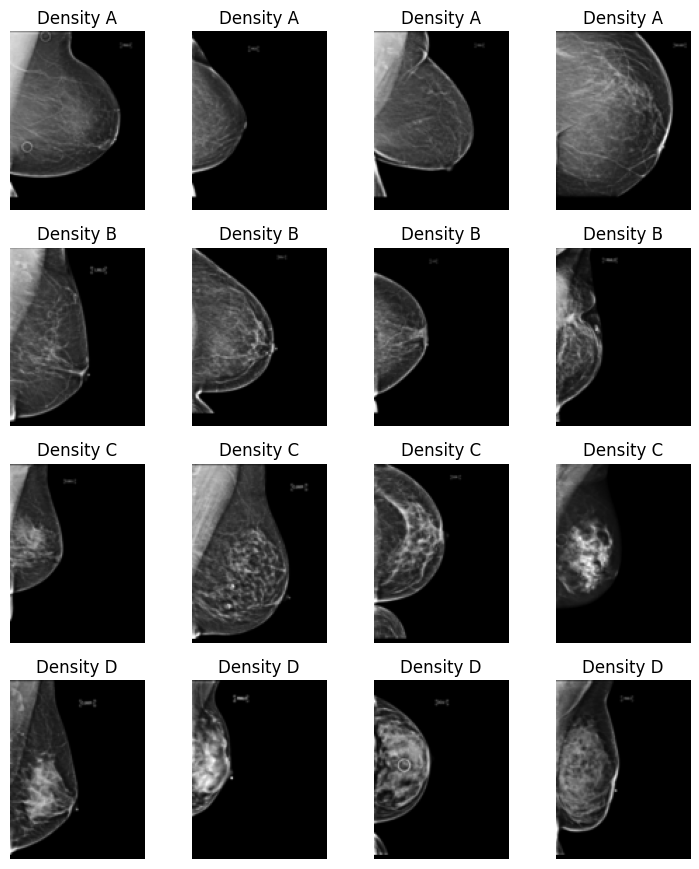

In [6]:
N_PER_CLASS = 4  # Number of images per class to display
CLASSES_DISPLAY = ["A", "B", "C", "D"] # Breast density classes for display

df_meta["img_path"] = [
    os.path.join(
        DATA_DIR, "images",
        str(df_meta.study_id.values[i]),
        str(df_meta.image_id.values[i]) + ".png"
    )
    for i in range(len(df_meta))
]

# display sample images from each class
fig, axes = plt.subplots(len(CLASSES_DISPLAY), N_PER_CLASS, figsize=(1.9 * N_PER_CLASS, 2.2 * len(CLASSES_DISPLAY)))
if N_PER_CLASS == 1: # In case of single column, expand dims
    axes = np.expand_dims(axes, axis=1)

for r, cls in enumerate(CLASSES_DISPLAY):
    sub = df_meta[df_meta["density"] == cls]
    k = min(N_PER_CLASS, len(sub))
    sample_idx = np.random.choice(len(sub), size=k, replace=False)
    samples = sub.iloc[sample_idx]
    for c in range(N_PER_CLASS):
        ax = axes[r, c]
        ax.axis("off")
        if c < k:
            img = imread(samples.iloc[c]["img_path"])
            ax.imshow(img, cmap="gray")
            ax.set_title(f"Density {cls}", fontsize=12)
plt.tight_layout()
plt.show()


## **Part A**: Choose a sensible data augmentation pipeline within the `MammoDataset` class.

We provide a custom [PyTorch Dataset](https://pytorch.org/tutorials/beginner/basics/data_tutorial.html) that manages the RSNA-SMBC dataset.

**TASK:** Implement data augmentation for mammography images. You can use the `torchvision.transforms.v2` module to select a sensible set of photometric and geometric transformations. Report your choices in the coursework report.

In [4]:
class MammoDataset(Dataset):
    def __init__(self, data, image_size, image_normalization, augmentation = False, cache_size = 0):
        self.image_normalization = image_normalization
        self.do_augment = augmentation

        self.geometric_augment = T.Compose([

            T.RandomHorizontalFlip(p=0.5),

            T.RandomApply(
                transforms=[T.RandomAffine(
                    degrees=10,              
                    translate=(0.05, 0.05), 
                    scale=(0.9, 1.1),        
                )],
                p=0.5
            ),
        ])


        self.photometric_augment = T.Compose([

            T.RandomApply(
                transforms=[T.ColorJitter(brightness=0.15, contrast=0.15)],
                p=0.5
            ),

            T.RandomApply(
                transforms=[T.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0))],
                p=0.3
            ),
        ])

        self.imagenet_normalize = T.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )

        # load metadata into numpy arrays for faster access
        self.img_paths = data.img_path.to_numpy()
        self.study_ids = data.study_id.to_numpy()
        self.image_ids = data.image_id.to_numpy()
        self.labels = data.labels.to_numpy()

        # cache for preprocessed images to speed up training after the first epoch
        self.cache = None
        self.use_cache = cache_size > 0
        if self.use_cache:
            self.cache = SharedCache(
                size_limit_gib=cache_size,
                dataset_len=self.labels.shape[0],
                data_dims=(1, image_size[0], image_size[1]),
                dtype=torch.float32,
            )

    def preprocess(self, image):
        # breast segmentation using connected components
        image_norm = image - np.min(image)
        image_norm = image_norm / np.max(image_norm)
        thresh = cv2.threshold(img_as_ubyte(image_norm), 5, 255, cv2.THRESH_BINARY)[1]
        nb_components, output, stats, _ = cv2.connectedComponentsWithStats(thresh, connectivity=4)

        # Find the largest non background component.
        max_label, _ = max(
            [(i, stats[i, cv2.CC_STAT_AREA]) for i in range(1, nb_components)],
            key=lambda x: x[1],
        )
        mask = output == max_label
        image[mask == 0] = 0

        return image

    def __len__(self):
        return self.labels.shape[0]

    def __getitem__(self, index):
        image = None

        if self.use_cache:
            image = self.cache.get_slot(index)

        if image is None:
            img_path = self.img_paths[index]
            image = imread(img_path).astype(np.float32)
            image = self.preprocess(image)
            image = torch.from_numpy(image).unsqueeze(0)
            if self.use_cache:
                self.cache.set_slot(index, image, allow_overwrite=True)

        image = image / self.image_normalization


        if self.do_augment:
            image = self.geometric_augment(image)

        image = image.repeat(3, 1, 1)


        if self.do_augment:
            image = self.photometric_augment(image)

        image = self.imagenet_normalize(image)

        return {
            'image': image,
            'label': self.labels[index],
            'study_id': self.study_ids[index],
            'image_id': self.image_ids[index]
        }

    def get_labels(self):
        return self.labels


We use a [LightningDataModule](https://lightning.ai/docs/pytorch/stable/data/datamodule.html) for preparing the RSNA-SMBC dataset and its training, validation and test splits. No changes required here but make sure that you understand what is happening within this module.

In [5]:
class MammoDataModule(pl.LightningDataModule):
    def __init__(self, data_dir, csv_file, image_size, batch_size, num_workers):
        super().__init__()
        self.data_dir = data_dir
        self.image_size = image_size
        self.batch_size = batch_size
        self.num_workers = num_workers

        # load metadata
        self.data = pd.read_csv(csv_file)

        # construct image paths from metadata
        self.data['img_path'] = [os.path.join(self.data_dir, 'images', str(self.data.study_id.values[idx]), str(self.data.image_id.values[idx]) + '.png') for idx in range(0, len(self.data))]

        # Define image labels based on breast density classes
        self.data['labels'] = self.data['density']
        self.data.loc[self.data['labels'] == 'A', 'labels'] = 0
        self.data.loc[self.data['labels'] == 'B', 'labels'] = 1
        self.data.loc[self.data['labels'] == 'C', 'labels'] = 2
        self.data.loc[self.data['labels'] == 'D', 'labels'] = 3

        # Use pre-defined splits to separate data into train, val and testing
        self.train_data = self.data[self.data['split'] == 'training']
        self.val_data = self.data[self.data['split'] == 'validation']
        self.test_data = self.data[self.data['split'] == 'test']

        # create dataset objects for each split
        self.train_set = MammoDataset(self.train_data, self.image_size, image_normalization=65535.0, augmentation=True, cache_size=2)
        self.val_set = MammoDataset(self.val_data, self.image_size, image_normalization=65535.0, augmentation=False, cache_size=0.5)
        self.test_set = MammoDataset(self.test_data, self.image_size, image_normalization=65535.0, augmentation=False)

        # print dataset statistics
        train_labels = self.train_set.get_labels()
        train_class_count = np.array([len(np.where(train_labels == t)[0]) for t in np.unique(train_labels)])

        val_labels = self.val_set.get_labels()
        val_class_count = np.array([len(np.where(val_labels == t)[0]) for t in np.unique(val_labels)])

        test_labels = self.test_set.get_labels()
        test_class_count = np.array([len(np.where(test_labels == t)[0]) for t in np.unique(test_labels)])

        print('samples (train): ',len(self.train_set))
        print('samples (val):   ',len(self.val_set))
        print('samples (test):  ',len(self.test_set))
        print('class counts (train): ', train_class_count)
        print('class counts (val):   ', val_class_count)
        print('class counts (test):  ', test_class_count)
        print('class % (train): ', np.array([f"{x:.2f}" for x in np.array(train_class_count/len(train_labels)*100.0)]))
        print('class % (val):   ', np.array([f"{x:.2f}" for x in np.array(val_class_count/len(val_labels)*100.0)]))
        print('class % (test):  ', np.array([f"{x:.2f}" for x in np.array(test_class_count/len(test_labels)*100.0)]))

    def train_dataloader(self):
        # we use ImbalancedDatasetSampler to handle class imbalance in the training set
        return DataLoader(dataset=self.train_set, batch_size=self.batch_size, sampler=ImbalancedDatasetSampler(self.train_set), num_workers=self.num_workers, pin_memory=True)

    def val_dataloader(self):
        return DataLoader(dataset=self.val_set, batch_size=self.batch_size, shuffle=False, num_workers=self.num_workers)

    def test_dataloader(self):
        return DataLoader(dataset=self.test_set, batch_size=self.batch_size, shuffle=False, num_workers=self.num_workers)

## **Part B**: Implement a sensible model for image classification within the `MammoNet` class.

We use a [LightningModule](https://lightning.ai/docs/pytorch/stable/common/lightning_module.html) for implementing the model and its training and testing steps.

**TASK:** Implement and try out different models suitable for the breast density prediction problem. Check out the `torchvision.models` module. Report your choices in the coursework report.

In [6]:
class MammoNet(pl.LightningModule):

    def __init__(self, num_classes, learning_rate=0.0001):
        super().__init__()
        self.num_classes = num_classes
        self.lr = learning_rate

        backbone = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

        num_features = backbone.fc.in_features


        backbone.fc = nn.Identity()

        self.backbone = backbone


        self.classifier = nn.Sequential(
            nn.Dropout(p=0.5),
            nn.Linear(num_features, self.num_classes)
        )

    def forward(self, x):
        features = self.backbone(x)
        return self.classifier(features)

    def get_embeddings(self, x):
        with torch.no_grad():
            features = self.backbone(x)
        return features

    def configure_optimizers(self):
        optimizer = torch.optim.Adam(
            self.parameters(), lr=self.lr, weight_decay=1e-5
        )
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode='max', factor=0.5, patience=3
        )
        return {
            'optimizer': optimizer,
            'lr_scheduler': {
                'scheduler': scheduler,
                'monitor': 'val_auc',
            }
        }

    def process_batch(self, batch):
        img, lab = batch['image'], batch['label']
        out = self.forward(img)
        prd = torch.softmax(out, dim=1)
        loss = F.cross_entropy(out, lab)
        return loss, prd, lab


    def on_train_epoch_start(self):
        self.train_preds = []
        self.train_trgts = []

    def training_step(self, batch, batch_idx):
        loss, prd, lab = self.process_batch(batch)
        self.log('train_loss', loss, batch_size=lab.shape[0])
        self.train_preds.append(prd.detach().cpu())
        self.train_trgts.append(lab.detach().cpu())
        if batch_idx == 0:
            images = batch['image'][0:4, ...].detach().cpu()
            grid = torchvision.utils.make_grid(images, nrow=2, normalize=True)
            self.logger.experiment.add_image('images', grid, self.global_step)
        return loss

    def on_train_epoch_end(self):
        self.train_preds = torch.cat(self.train_preds, dim=0)
        self.train_trgts = torch.cat(self.train_trgts, dim=0)
        auc = auroc(self.train_preds, self.train_trgts, num_classes=self.num_classes, average='macro', task='multiclass')
        self.log('train_auc', auc)
        self.train_preds = []
        self.train_trgts = []


    def on_validation_epoch_start(self):
        self.val_preds = []
        self.val_trgts = []

    def validation_step(self, batch, batch_idx):
        loss, prd, lab = self.process_batch(batch)
        self.log('val_loss', loss, batch_size=lab.shape[0])
        self.val_preds.append(prd.detach().cpu())
        self.val_trgts.append(lab.detach().cpu())

    def on_validation_epoch_end(self):
        self.val_preds = torch.cat(self.val_preds, dim=0)
        self.val_trgts = torch.cat(self.val_trgts, dim=0)
        auc = auroc(self.val_preds, self.val_trgts, num_classes=self.num_classes, average='macro', task='multiclass')
        self.log('val_auc', auc)
        self.val_preds = []
        self.val_trgts = []


    def on_test_epoch_start(self):
        self.test_preds = []
        self.test_trgts = []
        self.test_study_ids = []
        self.test_image_ids = []

    def test_step(self, batch, batch_idx):
        loss, prd, lab = self.process_batch(batch)
        self.log('test_loss', loss, batch_size=lab.shape[0])
        self.test_preds.append(prd.detach().cpu())
        self.test_trgts.append(lab.detach().cpu())
        self.test_study_ids.append(batch['study_id'].detach().cpu())
        self.test_image_ids.append(batch['image_id'].detach().cpu())

    def on_test_epoch_end(self):
        self.test_preds = torch.cat(self.test_preds, dim=0)
        self.test_trgts = torch.cat(self.test_trgts, dim=0)
        auc = auroc(self.test_preds, self.test_trgts, num_classes=self.num_classes, average='macro', task='multiclass')
        self.log('test_auc', auc)

In [7]:
class MammoNetDenseNet(pl.LightningModule):

    def __init__(self, num_classes, learning_rate=0.0001):
        super().__init__()
        self.num_classes = num_classes
        self.lr = learning_rate

        backbone = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1)

        num_features = backbone.classifier.in_features

        backbone.classifier = nn.Identity()

        self.backbone = backbone

        self.classifier = nn.Sequential(
            nn.Dropout(p=0.5),
            nn.Linear(num_features, self.num_classes)
        )

    def forward(self, x):
        features = self.backbone(x)
        return self.classifier(features)

    def get_embeddings(self, x):
        with torch.no_grad():
            features = self.backbone(x)
        return features

    def configure_optimizers(self):
        optimizer = torch.optim.Adam(
            self.parameters(), lr=self.lr, weight_decay=1e-5
        )
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode='max', factor=0.5, patience=3
        )
        return {
            'optimizer': optimizer,
            'lr_scheduler': {
                'scheduler': scheduler,
                'monitor': 'val_auc',
            }
        }

    def process_batch(self, batch):
        img, lab = batch['image'], batch['label']
        out = self.forward(img)
        prd = torch.softmax(out, dim=1)
        loss = F.cross_entropy(out, lab)
        return loss, prd, lab

    def on_train_epoch_start(self):
        self.train_preds = []
        self.train_trgts = []

    def training_step(self, batch, batch_idx):
        loss, prd, lab = self.process_batch(batch)
        self.log('train_loss', loss, batch_size=lab.shape[0])
        self.train_preds.append(prd.detach().cpu())
        self.train_trgts.append(lab.detach().cpu())
        if batch_idx == 0:
            images = batch['image'][0:4, ...].detach().cpu()
            grid = torchvision.utils.make_grid(images, nrow=2, normalize=True)
            self.logger.experiment.add_image('images', grid, self.global_step)
        return loss

    def on_train_epoch_end(self):
        self.train_preds = torch.cat(self.train_preds, dim=0)
        self.train_trgts = torch.cat(self.train_trgts, dim=0)
        auc = auroc(self.train_preds, self.train_trgts, num_classes=self.num_classes, average='macro', task='multiclass')
        self.log('train_auc', auc)
        self.train_preds = []
        self.train_trgts = []

    def on_validation_epoch_start(self):
        self.val_preds = []
        self.val_trgts = []

    def validation_step(self, batch, batch_idx):
        loss, prd, lab = self.process_batch(batch)
        self.log('val_loss', loss, batch_size=lab.shape[0])
        self.val_preds.append(prd.detach().cpu())
        self.val_trgts.append(lab.detach().cpu())

    def on_validation_epoch_end(self):
        self.val_preds = torch.cat(self.val_preds, dim=0)
        self.val_trgts = torch.cat(self.val_trgts, dim=0)
        auc = auroc(self.val_preds, self.val_trgts, num_classes=self.num_classes, average='macro', task='multiclass')
        self.log('val_auc', auc)
        self.val_preds = []
        self.val_trgts = []

    def on_test_epoch_start(self):
        self.test_preds = []
        self.test_trgts = []
        self.test_study_ids = []
        self.test_image_ids = []

    def test_step(self, batch, batch_idx):
        loss, prd, lab = self.process_batch(batch)
        self.log('test_loss', loss, batch_size=lab.shape[0])
        self.test_preds.append(prd.detach().cpu())
        self.test_trgts.append(lab.detach().cpu())
        self.test_study_ids.append(batch['study_id'].detach().cpu())
        self.test_image_ids.append(batch['image_id'].detach().cpu())

    def on_test_epoch_end(self):
        self.test_preds = torch.cat(self.test_preds, dim=0)
        self.test_trgts = torch.cat(self.test_trgts, dim=0)
        auc = auroc(self.test_preds, self.test_trgts, num_classes=self.num_classes, average='macro', task='multiclass')
        self.log('test_auc', auc)

In [ ]:
class MammoNetEfficientNet(pl.LightningModule):
    def __init__(self, num_classes, learning_rate=0.0001):
        super().__init__()
        self.num_classes = num_classes
        self.lr = learning_rate

        backbone = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)

        num_features = backbone.classifier[1].in_features

        backbone.classifier = nn.Identity()

        self.backbone = backbone

        self.classifier = nn.Sequential(
            nn.Dropout(p=0.5),
            nn.Linear(num_features, self.num_classes)
        )

    def forward(self, x):
        features = self.backbone(x)
        return self.classifier(features)

    def get_embeddings(self, x):
        with torch.no_grad():
            features = self.backbone(x)
        return features

    def configure_optimizers(self):
        optimizer = torch.optim.Adam(
            self.parameters(), lr=self.lr, weight_decay=1e-5
        )
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode='max', factor=0.5, patience=3
        )
        return {
            'optimizer': optimizer,
            'lr_scheduler': {
                'scheduler': scheduler,
                'monitor': 'val_auc',
            }
        }

    def process_batch(self, batch):
        img, lab = batch['image'], batch['label']
        out = self.forward(img)
        prd = torch.softmax(out, dim=1)
        loss = F.cross_entropy(out, lab)
        return loss, prd, lab

    def on_train_epoch_start(self):
        self.train_preds = []
        self.train_trgts = []

    def training_step(self, batch, batch_idx):
        loss, prd, lab = self.process_batch(batch)
        self.log('train_loss', loss, batch_size=lab.shape[0])
        self.train_preds.append(prd.detach().cpu())
        self.train_trgts.append(lab.detach().cpu())
        if batch_idx == 0:
            images = batch['image'][0:4, ...].detach().cpu()
            grid = torchvision.utils.make_grid(images, nrow=2, normalize=True)
            self.logger.experiment.add_image('images', grid, self.global_step)
        return loss

    def on_train_epoch_end(self):
        self.train_preds = torch.cat(self.train_preds, dim=0)
        self.train_trgts = torch.cat(self.train_trgts, dim=0)
        auc = auroc(self.train_preds, self.train_trgts, num_classes=self.num_classes, average='macro', task='multiclass')
        self.log('train_auc', auc)
        self.train_preds = []
        self.train_trgts = []

    def on_validation_epoch_start(self):
        self.val_preds = []
        self.val_trgts = []

    def validation_step(self, batch, batch_idx):
        loss, prd, lab = self.process_batch(batch)
        self.log('val_loss', loss, batch_size=lab.shape[0])
        self.val_preds.append(prd.detach().cpu())
        self.val_trgts.append(lab.detach().cpu())

    def on_validation_epoch_end(self):
        self.val_preds = torch.cat(self.val_preds, dim=0)
        self.val_trgts = torch.cat(self.val_trgts, dim=0)
        auc = auroc(self.val_preds, self.val_trgts, num_classes=self.num_classes, average='macro', task='multiclass')
        self.log('val_auc', auc)
        self.val_preds = []
        self.val_trgts = []

    def on_test_epoch_start(self):
        self.test_preds = []
        self.test_trgts = []
        self.test_study_ids = []
        self.test_image_ids = []

    def test_step(self, batch, batch_idx):
        loss, prd, lab = self.process_batch(batch)
        self.log('test_loss', loss, batch_size=lab.shape[0])
        self.test_preds.append(prd.detach().cpu())
        self.test_trgts.append(lab.detach().cpu())
        self.test_study_ids.append(batch['study_id'].detach().cpu())
        self.test_image_ids.append(batch['image_id'].detach().cpu())

    def on_test_epoch_end(self):
        self.test_preds = torch.cat(self.test_preds, dim=0)
        self.test_trgts = torch.cat(self.test_trgts, dim=0)
        auc = auroc(self.test_preds, self.test_trgts, num_classes=self.num_classes, average='macro', task='multiclass')
        self.log('test_auc', auc)

### Training - ResNet 18

We use the PyTorch Lightning [Trainer](https://lightning.ai/docs/pytorch/stable/common/trainer.html) for easy training and testing. You may need to adjust the number of epochs, but otherwise you should be able to just run the cell and wait for the training to complete.

**TASK:** Adjust the number of epochs if needed. Report any observations about the training in your coursework report (you may want to check training and validation curves via Tensorboard).

In [17]:
pl.seed_everything(42, workers=True)

output_base = './output/'
output_name = 'mammo-resnet18'
output_dir = os.path.join(output_base, output_name)

data = MammoDataModule(
    data_dir=DATA_DIR, csv_file=CSV_FILE,
    image_size=IMAGE_SIZE, batch_size=64, num_workers=4
)

model = MammoNet(num_classes=NUM_CLASSES, learning_rate=0.0001)

trainer = pl.Trainer(
    max_epochs=10,
    accelerator='auto',
    devices=1,
    log_every_n_steps=5,
    logger=TensorBoardLogger(save_dir=output_base, name=output_name),
    callbacks=[
        ModelCheckpoint(monitor="val_auc", mode='max', save_top_k=1),
        TQDMProgressBar(refresh_rate=10)
    ],
)
trainer.fit(model=model, datamodule=data)

INFO:lightning_fabric.utilities.seed:Seed set to 42


Dataset size (1.0 GiB) fits in cache limit (2 GiB). Allocating space to cache all 21204 samples.
Dataset size (0.1 GiB) fits in cache limit (0.5 GiB). Allocating space to cache all 2368 samples.
samples (train):  21204
samples (val):    2368
samples (test):   5865
class counts (train):  [2224 9057 8856 1067]
class counts (val):    [ 247 1034  938  149]
class counts (test):   [ 628 2548 2368  321]
class % (train):  ['10.49' '42.71' '41.77' '5.03']
class % (val):    ['10.43' '43.67' '39.61' '6.29']
class % (test):   ['10.71' '43.44' '40.38' '5.47']


INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name       ┃ Type       ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ backbone   │ ResNet     │ 11.2 M │ train │     0 │
│ 1 │ classifier │ Sequential │  2.1 K │ train │     0 │
└───┴────────────┴────────────┴────────┴───────┴───────┘

Trainable params: 11.2 M                                                                                           
Non-trainable params: 0                                                                                            
Total params: 11.2 M                                                                                               
Total estimated model params size (MB): 44                                                                         
Modules in train mode: 71                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=10` reached.


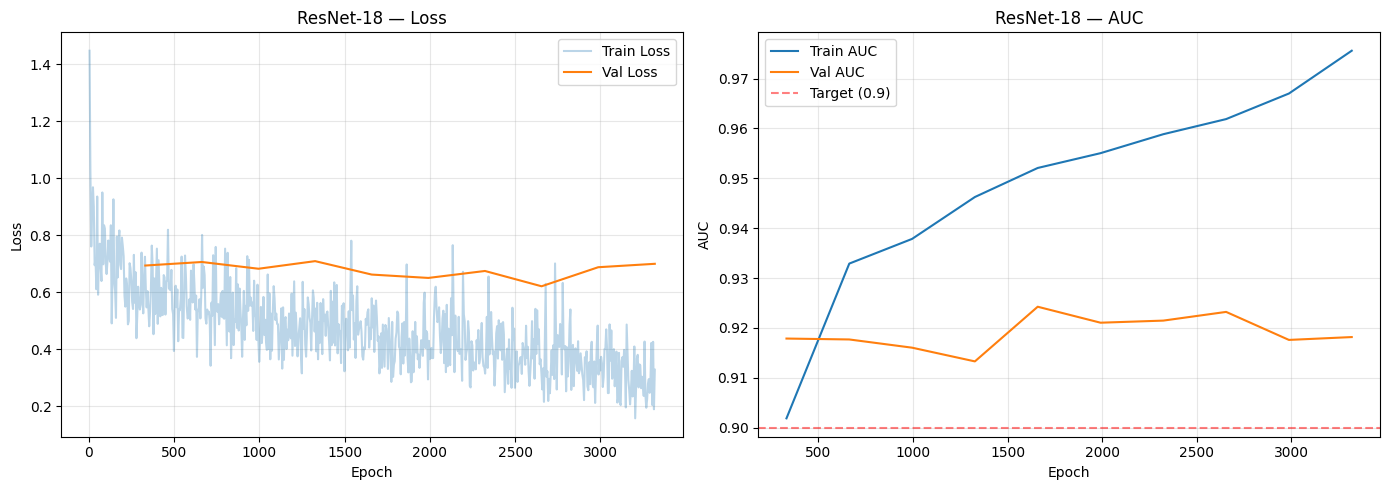

In [ ]:
from pytorch_lightning.utilities import rank_zero_only
from tensorboard.backend.event_processing import event_accumulator
import glob

def plot_training_curves(log_dir, model_name):

    event_files = glob.glob(os.path.join(log_dir, '**', 'events.out.*'), recursive=True)
    if not event_files:
        print(f"No TensorBoard event files found in {log_dir}")
        return

    event_file_dir = os.path.dirname(sorted(event_files)[-1])

    ea = event_accumulator.EventAccumulator(event_file_dir)
    ea.Reload()

    available_tags = ea.Tags()['scalars']

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    ax = axes[0]
    if 'train_loss_epoch' in available_tags:
        train_loss = [(s.step, s.value) for s in ea.Scalars('train_loss_epoch')]
        ax.plot([x[0] for x in train_loss], [x[1] for x in train_loss], label='Train Loss', color='tab:blue')
    elif 'train_loss' in available_tags:
        train_loss = [(s.step, s.value) for s in ea.Scalars('train_loss')]
        ax.plot([x[0] for x in train_loss], [x[1] for x in train_loss], label='Train Loss', color='tab:blue', alpha=0.3)

    if 'val_loss' in available_tags:
        val_loss = [(s.step, s.value) for s in ea.Scalars('val_loss')]
        ax.plot([x[0] for x in val_loss], [x[1] for x in val_loss], label='Val Loss', color='tab:orange')

    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.set_title(f'{model_name} — Loss')
    ax.legend()
    ax.grid(True, alpha=0.3)

    ax = axes[1]
    if 'train_auc' in available_tags:
        train_auc = [(s.step, s.value) for s in ea.Scalars('train_auc')]
        ax.plot([x[0] for x in train_auc], [x[1] for x in train_auc], label='Train AUC', color='tab:blue')

    if 'val_auc' in available_tags:
        val_auc = [(s.step, s.value) for s in ea.Scalars('val_auc')]
        ax.plot([x[0] for x in val_auc], [x[1] for x in val_auc], label='Val AUC', color='tab:orange')

    ax.set_xlabel('Epoch')
    ax.set_ylabel('AUC')
    ax.set_title(f'{model_name} — AUC')
    ax.axhline(y=0.9, color='red', linestyle='--', alpha=0.5, label='Target (0.9)')
    ax.legend()
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(os.path.join(output_base, f'{model_name.lower().replace(" ", "_")}_curves.png'), dpi=150, bbox_inches='tight')
    plt.show()

plot_training_curves(os.path.join(output_base, output_name), 'ResNet-18')

### Validation - ResNet 18

Evaluate the trained model with the best checkpoint on the validation data and report the classification performance.

**TASK:** You should report the validation performance and some information about the model checkpoint in the coursework report (at what epoch/iteration did you find the best checkpoint).

In [ ]:
trainer.validate(model=model, datamodule=data, ckpt_path=trainer.checkpoint_callback.best_model_path)

INFO:pytorch_lightning.utilities.rank_zero:Restoring states from the checkpoint path at ./output/mammo-resnet18/version_1/checkpoints/epoch=4-step=1660.ckpt
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.utilities.rank_zero:Loaded model weights from the checkpoint at ./output/mammo-resnet18/version_1/checkpoints/epoch=4-step=1660.ckpt


Validation: |          | 0/? [00:00<?, ?it/s]

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│          val_auc          │    0.9242503643035889     │
│         val_loss          │    0.6621347069740295     │
└───────────────────────────┴───────────────────────────┘

[{'val_loss': 0.6621347069740295, 'val_auc': 0.9242503643035889}]

### Testing - ResNet 18

Evaluate the trained model with the best checkpoint on the test data and report the classification performance.

**TASK:** You should report the test performance in the coursework report.

In [20]:
def save_predictions(model, output_fname):
    std_ids = [id.numpy() for sublist in model.test_study_ids for id in sublist]
    img_ids = [id.numpy() for sublist in model.test_image_ids for id in sublist]
    cols_names = ['class_' + str(i) for i in range(0, NUM_CLASSES)]
    df = pd.DataFrame(data=model.test_preds.numpy(), columns=cols_names)
    df['target'] = model.test_trgts.numpy()
    df['study_id'] = std_ids
    df['image_id'] = img_ids
    df.to_csv(output_fname, index=False)

In [ ]:
trainer.test(model=model, datamodule=data, ckpt_path=trainer.checkpoint_callback.best_model_path)
print("=" * 60)
print("MODEL 1: ResNet-18 — Results")
print("=" * 60)
print(f"Best checkpoint: {trainer.checkpoint_callback.best_model_path}")
print(f"Best val AUC:    {trainer.checkpoint_callback.best_model_score:.4f}")

import re
ckpt_path = trainer.checkpoint_callback.best_model_path
epoch_match = re.search(r'epoch=(\d+)', ckpt_path)
if epoch_match:
    print(f"Best epoch:      {int(epoch_match.group(1))}")

from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import label_binarize

test_preds_np = model.test_preds.numpy()
test_trgts_np = model.test_trgts.numpy()
test_trgts_bin = label_binarize(test_trgts_np, classes=[0, 1, 2, 3])

class_names = ['A (fatty)', 'B (scattered)', 'C (heterogeneous)', 'D (extremely dense)']

print("\nPer-class AUC (one-vs-rest):")
for i, name in enumerate(class_names):
    class_auc = roc_auc_score(test_trgts_bin[:, i], test_preds_np[:, i])
    print(f"  Class {name}: {class_auc:.4f}")

macro_auc = roc_auc_score(test_trgts_bin, test_preds_np, average='macro', multi_class='ovr')
print(f"\nMacro AUC (test): {macro_auc:.4f}")
print("=" * 60)

save_predictions(model=model, output_fname=os.path.join(output_dir, 'predictions.csv'))

INFO:pytorch_lightning.utilities.rank_zero:Restoring states from the checkpoint path at ./output/mammo-resnet18/version_1/checkpoints/epoch=4-step=1660.ckpt
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.utilities.rank_zero:Loaded model weights from the checkpoint at ./output/mammo-resnet18/version_1/checkpoints/epoch=4-step=1660.ckpt


Testing: |          | 0/? [00:00<?, ?it/s]

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_auc          │    0.9158496856689453     │
│         test_loss         │    0.6881226897239685     │
└───────────────────────────┴───────────────────────────┘

MODEL 1: ResNet-18 — Results
Best checkpoint: ./output/mammo-resnet18/version_1/checkpoints/epoch=4-step=1660.ckpt
Best val AUC:    0.9243
Best epoch:      4

Per-class AUC (one-vs-rest):
  Class A (fatty): 0.9430
  Class B (scattered): 0.8667
  Class C (heterogeneous): 0.8915
  Class D (extremely dense): 0.9622

Macro AUC (test): 0.9158


## Model 2: DenseNet-121 (for comparison)

INFO:lightning_fabric.utilities.seed:Seed set to 42


Dataset size (1.0 GiB) fits in cache limit (2 GiB). Allocating space to cache all 21204 samples.
Dataset size (0.1 GiB) fits in cache limit (0.5 GiB). Allocating space to cache all 2368 samples.
samples (train):  21204
samples (val):    2368
samples (test):   5865
class counts (train):  [2224 9057 8856 1067]
class counts (val):    [ 247 1034  938  149]
class counts (test):   [ 628 2548 2368  321]
class % (train):  ['10.49' '42.71' '41.77' '5.03']
class % (val):    ['10.43' '43.67' '39.61' '6.29']
class % (test):   ['10.71' '43.44' '40.38' '5.47']


INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name       ┃ Type       ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ backbone   │ DenseNet   │  7.0 M │ train │     0 │
│ 1 │ classifier │ Sequential │  4.1 K │ train │     0 │
└───┴────────────┴────────────┴────────┴───────┴───────┘

Trainable params: 7.0 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 7.0 M                                                                                                
Total estimated model params size (MB): 27                                                                         
Modules in train mode: 436                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=10` reached.


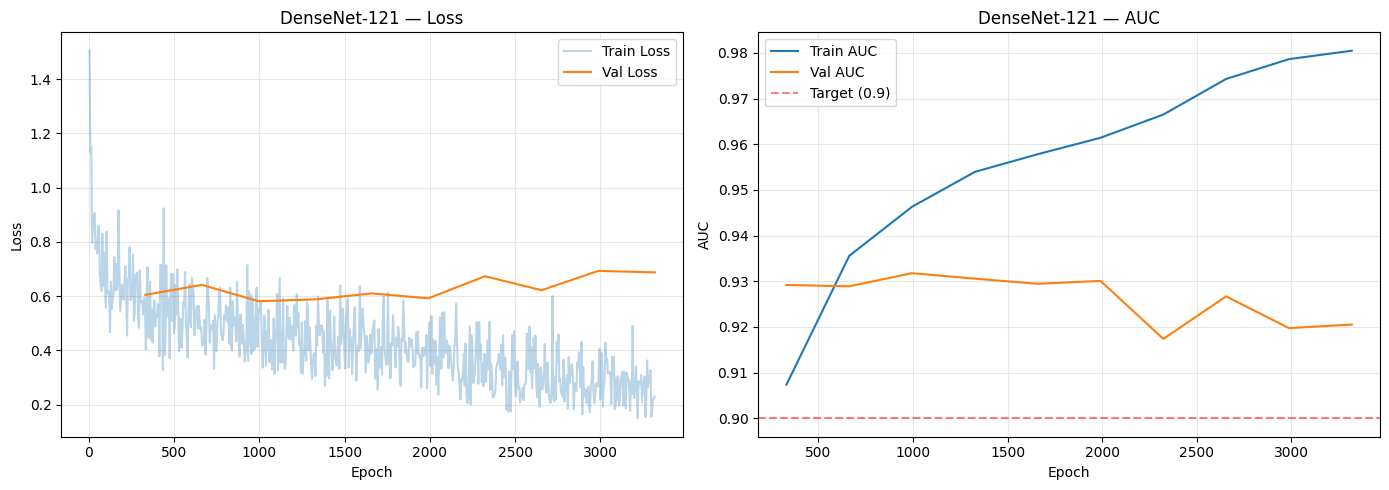

INFO:pytorch_lightning.utilities.rank_zero:Restoring states from the checkpoint path at ./output/mammo-densenet121/version_1/checkpoints/epoch=2-step=996.ckpt
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.utilities.rank_zero:Loaded model weights from the checkpoint at ./output/mammo-densenet121/version_1/checkpoints/epoch=2-step=996.ckpt


Validation: |          | 0/? [00:00<?, ?it/s]

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│          val_auc          │    0.9317742586135864     │
│         val_loss          │    0.5813509821891785     │
└───────────────────────────┴───────────────────────────┘

INFO:pytorch_lightning.utilities.rank_zero:Restoring states from the checkpoint path at ./output/mammo-densenet121/version_1/checkpoints/epoch=2-step=996.ckpt
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.utilities.rank_zero:Loaded model weights from the checkpoint at ./output/mammo-densenet121/version_1/checkpoints/epoch=2-step=996.ckpt


Testing: |          | 0/? [00:00<?, ?it/s]

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_auc          │    0.9195173382759094     │
│         test_loss         │    0.6236422061920166     │
└───────────────────────────┴───────────────────────────┘

MODEL 2: DenseNet-121 — Results
Best checkpoint: ./output/mammo-densenet121/version_1/checkpoints/epoch=2-step=996.ckpt
Best val AUC:    0.9318
Best epoch:      2

Per-class AUC (one-vs-rest):
  Class A (fatty): 0.9501
  Class B (scattered): 0.8633
  Class C (heterogeneous): 0.8988
  Class D (extremely dense): 0.9658

Macro AUC (test): 0.9195


In [ ]:
pl.seed_everything(42, workers=True)

output_name_2 = 'mammo-densenet121'
output_dir_2 = os.path.join(output_base, output_name_2)

data2 = MammoDataModule(
    data_dir=DATA_DIR, csv_file=CSV_FILE,
    image_size=IMAGE_SIZE, batch_size=64, num_workers=4
)

model2 = MammoNetDenseNet(num_classes=NUM_CLASSES, learning_rate=0.0001)

trainer2 = pl.Trainer(
    max_epochs=10,
    accelerator='auto',
    devices=1,
    log_every_n_steps=5,
    logger=TensorBoardLogger(save_dir=output_base, name=output_name_2),
    callbacks=[
        ModelCheckpoint(monitor="val_auc", mode='max', save_top_k=1),
        TQDMProgressBar(refresh_rate=10)
    ],
)
trainer2.fit(model=model2, datamodule=data2)

plot_training_curves(os.path.join(output_base, output_name_2), 'DenseNet-121')

trainer2.validate(model=model2, datamodule=data2, ckpt_path=trainer2.checkpoint_callback.best_model_path)

trainer2.test(model=model2, datamodule=data2, ckpt_path=trainer2.checkpoint_callback.best_model_path)


print("=" * 60)
print("MODEL 2: DenseNet-121 — Results")
print("=" * 60)
print(f"Best checkpoint: {trainer2.checkpoint_callback.best_model_path}")
print(f"Best val AUC:    {trainer2.checkpoint_callback.best_model_score:.4f}")

ckpt_path2 = trainer2.checkpoint_callback.best_model_path
epoch_match2 = re.search(r'epoch=(\d+)', ckpt_path2)
if epoch_match2:
    print(f"Best epoch:      {int(epoch_match2.group(1))}")

test_preds_np2 = model2.test_preds.numpy()
test_trgts_np2 = model2.test_trgts.numpy()
test_trgts_bin2 = label_binarize(test_trgts_np2, classes=[0, 1, 2, 3])

print("\nPer-class AUC (one-vs-rest):")
for i, name in enumerate(class_names):
    class_auc = roc_auc_score(test_trgts_bin2[:, i], test_preds_np2[:, i])
    print(f"  Class {name}: {class_auc:.4f}")

macro_auc2 = roc_auc_score(test_trgts_bin2, test_preds_np2, average='macro', multi_class='ovr')
print(f"\nMacro AUC (test): {macro_auc2:.4f}")
print("=" * 60)
save_predictions(model=model2, output_fname=os.path.join(output_dir_2, 'predictions_densenet.csv'))

## Model 3: EfficientNet-B0 (for comparison)

INFO:lightning_fabric.utilities.seed:Seed set to 42


Dataset size (1.0 GiB) fits in cache limit (2 GiB). Allocating space to cache all 21204 samples.
Dataset size (0.1 GiB) fits in cache limit (0.5 GiB). Allocating space to cache all 2368 samples.
samples (train):  21204
samples (val):    2368
samples (test):   5865
class counts (train):  [2224 9057 8856 1067]
class counts (val):    [ 247 1034  938  149]
class counts (test):   [ 628 2548 2368  321]
class % (train):  ['10.49' '42.71' '41.77' '5.03']
class % (val):    ['10.43' '43.67' '39.61' '6.29']
class % (test):   ['10.71' '43.44' '40.38' '5.47']
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 166MB/s]
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name       ┃ Type         ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ backbone   │ EfficientNet │  4.0 M │ train │     0 │
│ 1 │ classifier │ Sequential   │  5.1 K │ train │     0 │
└───┴────────────┴──────────────┴────────┴───────┴───────┘

Trainable params: 4.0 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 4.0 M                                                                                                
Total estimated model params size (MB): 16                                                                         
Modules in train mode: 338                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=10` reached.


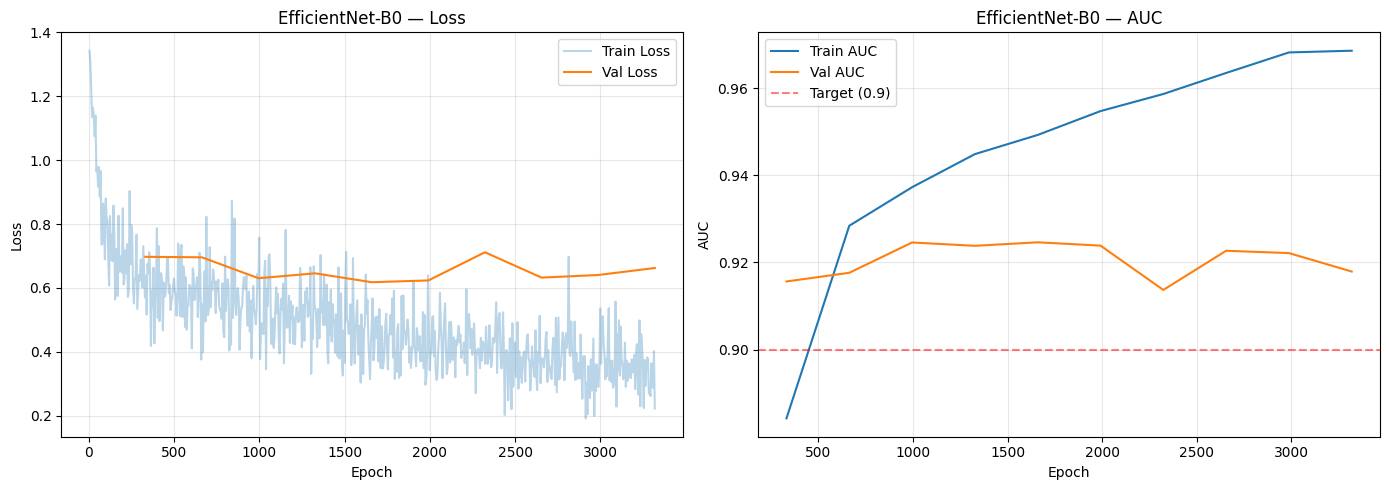

INFO:pytorch_lightning.utilities.rank_zero:Restoring states from the checkpoint path at ./output/mammo-efficientnet/version_0/checkpoints/epoch=4-step=1660.ckpt
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.utilities.rank_zero:Loaded model weights from the checkpoint at ./output/mammo-efficientnet/version_0/checkpoints/epoch=4-step=1660.ckpt


Validation: |          | 0/? [00:00<?, ?it/s]

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│          val_auc          │    0.9246276617050171     │
│         val_loss          │    0.6179477572441101     │
└───────────────────────────┴───────────────────────────┘

INFO:pytorch_lightning.utilities.rank_zero:Restoring states from the checkpoint path at ./output/mammo-efficientnet/version_0/checkpoints/epoch=4-step=1660.ckpt
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.utilities.rank_zero:Loaded model weights from the checkpoint at ./output/mammo-efficientnet/version_0/checkpoints/epoch=4-step=1660.ckpt


Testing: |          | 0/? [00:00<?, ?it/s]

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_auc          │    0.9185956120491028     │
│         test_loss         │    0.6295003890991211     │
└───────────────────────────┴───────────────────────────┘

MODEL 3: EfficientNet-B0 — Results
Best checkpoint: ./output/mammo-efficientnet/version_0/checkpoints/epoch=4-step=1660.ckpt
Best val AUC:    0.9246
Best epoch:      4

Per-class AUC (one-vs-rest):
  Class A (fatty): 0.9505
  Class B (scattered): 0.8635
  Class C (heterogeneous): 0.9036
  Class D (extremely dense): 0.9568

Macro AUC (test): 0.9186


In [ ]:
pl.seed_everything(42, workers=True)

output_name_3 = 'mammo-efficientnet'
output_dir_3 = os.path.join(output_base, output_name_3)

data3 = MammoDataModule(
    data_dir=DATA_DIR, csv_file=CSV_FILE,
    image_size=IMAGE_SIZE, batch_size=64, num_workers=4
)

model3 = MammoNetEfficientNet(num_classes=NUM_CLASSES, learning_rate=0.0001)

trainer3 = pl.Trainer(
    max_epochs=10,
    accelerator='auto',
    devices=1,
    log_every_n_steps=5,
    logger=TensorBoardLogger(save_dir=output_base, name=output_name_3),
    callbacks=[
        ModelCheckpoint(monitor="val_auc", mode='max', save_top_k=1),
        TQDMProgressBar(refresh_rate=10)
    ],
)
trainer3.fit(model=model3, datamodule=data3)

plot_training_curves(os.path.join(output_base, output_name_3), 'EfficientNet-B0')

trainer3.validate(model=model3, datamodule=data3, ckpt_path=trainer3.checkpoint_callback.best_model_path)

trainer3.test(model=model3, datamodule=data3, ckpt_path=trainer3.checkpoint_callback.best_model_path)

print("=" * 60)
print("MODEL 3: EfficientNet-B0 — Results")
print("=" * 60)
print(f"Best checkpoint: {trainer3.checkpoint_callback.best_model_path}")
print(f"Best val AUC:    {trainer3.checkpoint_callback.best_model_score:.4f}")

ckpt_path3 = trainer3.checkpoint_callback.best_model_path
epoch_match3 = re.search(r'epoch=(\d+)', ckpt_path3)
if epoch_match3:
    print(f"Best epoch:      {int(epoch_match3.group(1))}")

test_preds_np3 = model3.test_preds.numpy()
test_trgts_np3 = model3.test_trgts.numpy()
test_trgts_bin3 = label_binarize(test_trgts_np3, classes=[0, 1, 2, 3])

print("\nPer-class AUC (one-vs-rest):")
for i, name in enumerate(class_names):
    class_auc = roc_auc_score(test_trgts_bin3[:, i], test_preds_np3[:, i])
    print(f"  Class {name}: {class_auc:.4f}")

macro_auc3 = roc_auc_score(test_trgts_bin3, test_preds_np3, average='macro', multi_class='ovr')
print(f"\nMacro AUC (test): {macro_auc3:.4f}")
print("=" * 60)
save_predictions(model=model3, output_fname=os.path.join(output_dir_3, 'predictions_efficientnet.csv'))


In [28]:
print("\n" + "=" * 70)
print("FINAL MODEL COMPARISON")
print("=" * 70)
print(f"{'Model':<20} {'Val AUC':>10} {'Test AUC':>10} {'Best Epoch':>12}")
print("-" * 70)
print(f"{'ResNet-18':<20} {trainer.checkpoint_callback.best_model_score:>10.4f} {macro_auc:>10.4f} {int(epoch_match.group(1)):>12}")
print(f"{'DenseNet-121':<20} {trainer2.checkpoint_callback.best_model_score:>10.4f} {macro_auc2:>10.4f} {int(epoch_match2.group(1)):>12}")
print(f"{'EfficientNet-B0':<20} {trainer3.checkpoint_callback.best_model_score:>10.4f} {macro_auc3:>10.4f} {int(epoch_match3.group(1)):>12}")
print("=" * 70)


FINAL MODEL COMPARISON
Model                   Val AUC   Test AUC   Best Epoch
----------------------------------------------------------------------
ResNet-18                0.9243     0.9158            4
DenseNet-121             0.9318     0.9195            2
EfficientNet-B0          0.9246     0.9186            4


In [ ]:
def plot_model_comparison(model_names, val_aucs, test_aucs, per_class_aucs=None):
    if per_class_aucs is not None:
        fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    else:
        fig, axes = plt.subplots(1, 1, figsize=(8, 5))
        axes = [axes]

    ax = axes[0]
    x = np.arange(len(model_names))
    width = 0.35

    bars1 = ax.bar(x - width/2, val_aucs, width, label='Val AUC', color='tab:blue', alpha=0.8)
    bars2 = ax.bar(x + width/2, test_aucs, width, label='Test AUC', color='tab:orange', alpha=0.8)

    for bar in bars1:
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=10)
    for bar in bars2:
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=10)

    ax.axhline(y=0.9, color='red', linestyle='--', alpha=0.5, label='Target (0.9)')
    ax.set_ylabel('AUC')
    ax.set_title('Model Comparison — Macro AUC')
    ax.set_xticks(x)
    ax.set_xticklabels(model_names)
    ax.legend()
    ax.set_ylim(0.7, 1.0)
    ax.grid(True, alpha=0.3, axis='y')

    if per_class_aucs is not None:
        ax2 = axes[1]
        class_names_short = ['A\n(fatty)', 'B\n(scattered)', 'C\n(heterog.)', 'D\n(dense)']

        heatmap_data = np.array([per_class_aucs[name] for name in model_names])

        im = ax2.imshow(heatmap_data, cmap='RdYlGn', aspect='auto', vmin=0.75, vmax=1.0)

        ax2.set_xticks(np.arange(4))
        ax2.set_xticklabels(class_names_short)
        ax2.set_yticks(np.arange(len(model_names)))
        ax2.set_yticklabels(model_names)
        ax2.set_title('Per-Class AUC (one-vs-rest)')

        for i in range(len(model_names)):
            for j in range(4):
                ax2.text(j, i, f'{heatmap_data[i, j]:.3f}',
                        ha='center', va='center', fontsize=11,
                        color='black' if heatmap_data[i, j] > 0.85 else 'white')

        plt.colorbar(im, ax=ax2, shrink=0.8)

    plt.tight_layout()
    plt.savefig(os.path.join(output_base, 'model_comparison.png'), dpi=150, bbox_inches='tight')
    plt.show()

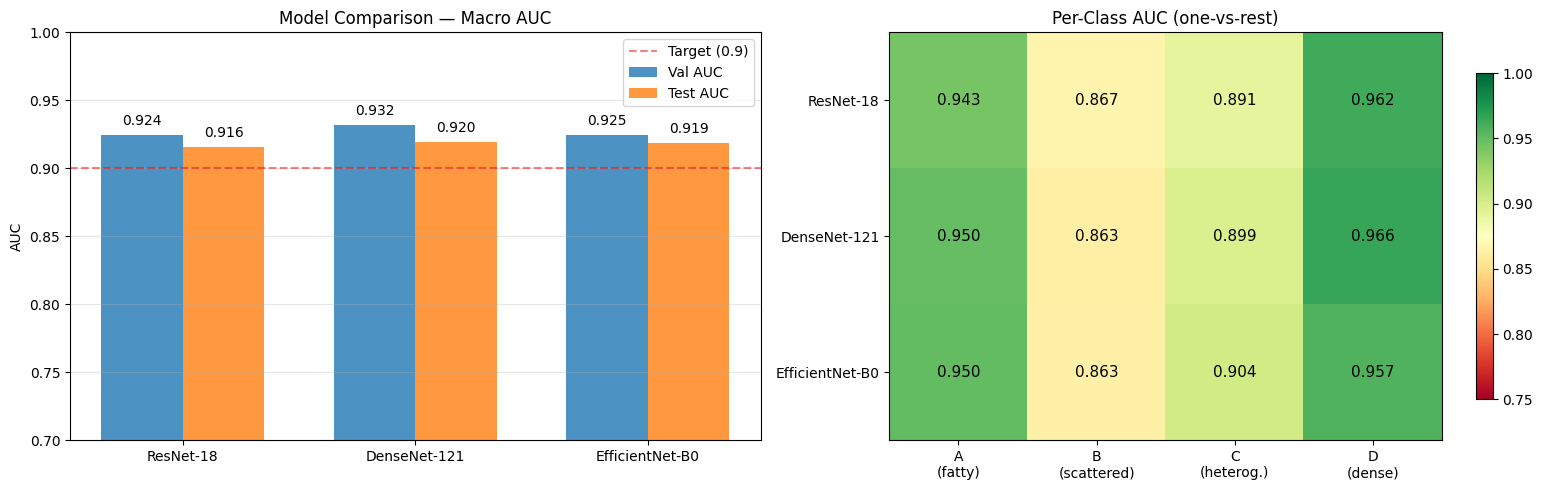

In [ ]:
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import label_binarize

per_class = {}
for name, preds, trgts in [
    ('ResNet-18', model.test_preds.numpy(), model.test_trgts.numpy()),
    ('DenseNet-121', model2.test_preds.numpy(), model2.test_trgts.numpy()),
    ('EfficientNet-B0', model3.test_preds.numpy(), model3.test_trgts.numpy()),
]:
    trgts_bin = label_binarize(trgts, classes=[0, 1, 2, 3])
    per_class[name] = [roc_auc_score(trgts_bin[:, i], preds[:, i]) for i in range(4)]

val_aucs = [
    trainer.checkpoint_callback.best_model_score.item(),
    trainer2.checkpoint_callback.best_model_score.item(),
    trainer3.checkpoint_callback.best_model_score.item(),
]

test_aucs = [
    roc_auc_score(label_binarize(model.test_trgts.numpy(), classes=[0,1,2,3]), model.test_preds.numpy(), average='macro', multi_class='ovr'),
    roc_auc_score(label_binarize(model2.test_trgts.numpy(), classes=[0,1,2,3]), model2.test_preds.numpy(), average='macro', multi_class='ovr'),
    roc_auc_score(label_binarize(model3.test_trgts.numpy(), classes=[0,1,2,3]), model3.test_preds.numpy(), average='macro', multi_class='ovr'),
]

plot_model_comparison(
    model_names=['ResNet-18', 'DenseNet-121', 'EfficientNet-B0'],
    val_aucs=val_aucs,
    test_aucs=test_aucs,
    per_class_aucs=per_class
)

## **Part C**: Conduct a subgroup performance analysis.

The code below allows you to check the model performance by plotting the [ROC curves](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.roc_curve.html) and calculating the per-class [AUC](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.auc.html) metrics over the whole test set.

**TASK:** Using different attributes from the meta information, conduct several subgroup performance analyses, and report the results in the coursework report. Note any interesting observations.

In [8]:
output_dir = "./output/mammo-densenet121/"
df_pred = pd.read_csv(os.path.join(output_dir, 'predictions_densenet.csv'))

In [4]:
class_columns = [col for col in df_pred.columns if col.startswith('class_')]
preds = np.stack([df_pred[col] for col in class_columns]).T
targets = np.array(df_pred['target'])

roc_results = {}

for i, class_name in enumerate(class_columns):
    pos_label = i
    y = np.array(targets)
    y[targets != pos_label] = 0
    y[targets == pos_label] = 1

    fpr, tpr, _ = roc_curve(y, preds[:, pos_label])
    roc_auc = auc(fpr, tpr)

    roc_results[class_name] = {
        'fpr': fpr,
        'tpr': tpr,
        'roc_auc': roc_auc
    }

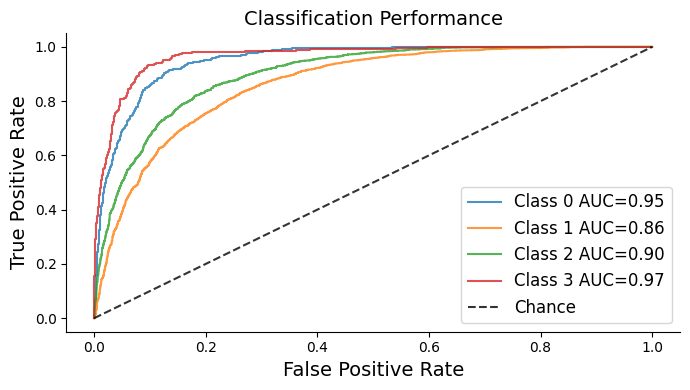

In [5]:
fig, ax = plt.subplots(figsize=(7, 4))

for i, (class_name, metrics) in enumerate(roc_results.items()):
    label = f"Class {i} AUC={metrics['roc_auc']:.2f}"
    plt.plot(metrics['fpr'], metrics['tpr'], lw=1.5, alpha=.8, label=label)

ax.plot([0, 1], [0, 1], linestyle='--', lw=1.5, color='k', label='Chance', alpha=.8)
plt.xlabel('False Positive Rate', fontsize=14)
plt.ylabel('True Positive Rate', fontsize=14)
plt.legend(loc="lower right", fontsize=12)
plt.title('Classification Performance', fontsize=14)
ax.set(xlim=[-0.05, 1.05], ylim=[-0.05, 1.05])
ax.spines[['right', 'top']].set_visible(False)
plt.tight_layout()

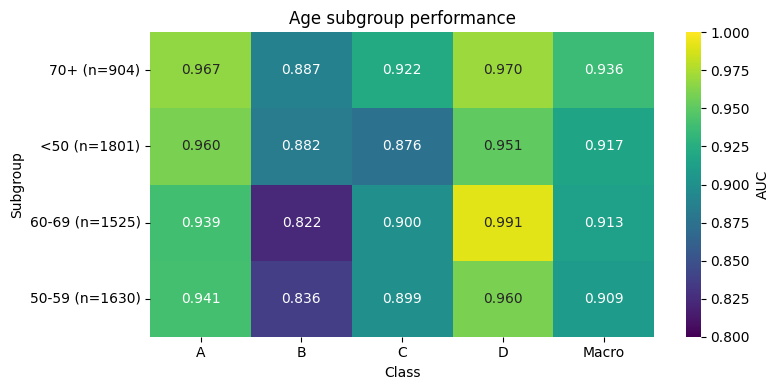

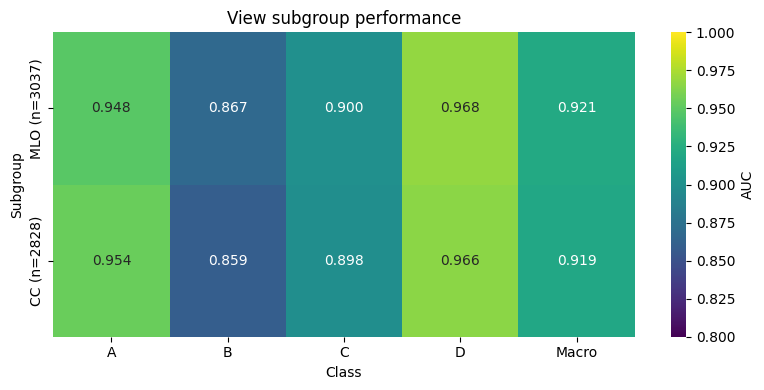

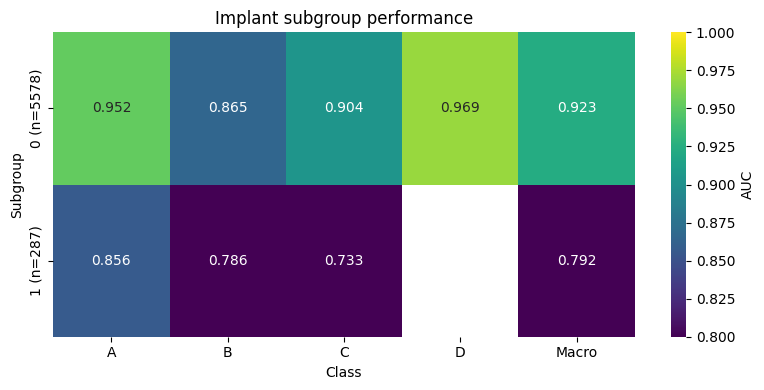

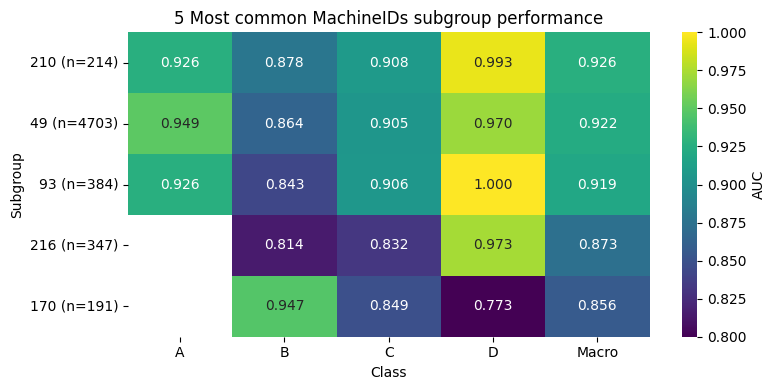

In [6]:
# load metadata
df_meta = pd.read_csv("data/rsna-small/meta.csv")
# keep test data only
df_meta_test = df_meta[df_meta["split"] == "test"].copy()

# merge predictions with meta data: inner join in order to keep rows present in both
df = df_pred.merge(df_meta_test, on="image_id", how="inner", suffixes=("", "_meta"))
# sanity check
assert(len(df) == len(df_pred))

# convert to numeric and remove invalid values
df["age"] = pd.to_numeric(df["age"], errors="coerce")
# convert continuous variable age into categorical variable belonging to a bin
df["age_bin"] = pd.cut(df["age"], bins=[0, 50, 60, 70, 150], 
                       labels=["<50", "50-59", "60-69", "70+"], right=False)


def subgroup_auc_table(df_all: pd.DataFrame, group_col: str, *,  top_k: int | None = None, min_group_n: int = 50, min_pos: int = 5
                      ) -> pd.DataFrame:
    """
    Compute one-vs-rest AUC per class for each subgroup and return a summary table.
    AUC = P("model gives higher score to a true class-k sample than to a non-class-k sample")
    
    Parameters
    ----------
    df_all : merged dataframe (predictions + meta)
    group_col : column used to define subgroups (e.g. "age_bin", "view")
    top_k : keep only the top_k most frequent groups (useful for machine_id)
    min_group_n : skip groups with too few samples
    min_pos : minimum positives (and negatives) required to compute ROC

    Returns
    -------
    DataFrame with:
        group_value
        n (#samples)
        auc_0 … auc_3
        macro_auc
    """

    rows = []

    # Optionally keep only the most frequent subgroup values
    if top_k is not None:
        keep_values = (df_all[group_col].value_counts().head(top_k).index)
        df_use = df_all[df_all[group_col].isin(keep_values)]
    else:
        df_use = df_all

    # Loop over each subgroup
    for g_value, df_g in df_use.groupby(group_col, observed=True):

        n = len(df_g)
        if n < min_group_n:   
            continue

        preds = df_g[class_columns].values
        targets = df_g["target"].values

        aucs = []

        # One-vs-rest AUC for each class
        for k in range(len(class_columns)):

            y = (targets == k).astype(int)

            # Need both positive and negative samples
            if len(np.unique(y)) < 2 or y.sum() < min_pos:
                aucs.append(np.nan)
                continue

            fpr, tpr, _ = roc_curve(y, preds[:, k])
            aucs.append(auc(fpr, tpr))

        macro_auc = np.nanmean(aucs)

        rows.append({
            "group_value": g_value,
            "n": n,
            **{f"auc_{i}": aucs[i] for i in range(len(aucs))},
            "macro_auc": macro_auc
        })

    return (
        pd.DataFrame(rows)
        .sort_values("macro_auc", ascending=False)
        .reset_index(drop=True)
    )
    
# Nice visualisation of subgroup AUC table (per-class AUC + macro)
def plot_auc_heatmap(summary_df: pd.DataFrame, title: str):
    df_plot = summary_df.copy()

    # Order rows by macro AUC (best at top)
    df_plot = df_plot.sort_values("macro_auc", ascending=False)
    
    # build label with sample size (new column in the dataframe)
    df_plot["group_label"] = (df_plot["group_value"].astype(str) + 
                              " (n=" + df_plot["n"].astype(int).astype(str) + ")" )

    # rename columns for plotting
    rename = {
        "auc_0": "A",
        "auc_1": "B",
        "auc_2": "C",
        "auc_3": "D",
        "macro_auc": "Macro",
    }
    df_plot = df_plot.rename(columns=rename)
    
    # Keep only the columns we want to display
    heatmap_cols = ["A", "B", "C", "D", "Macro"]
    # Set subgroup as index
    df_plot = df_plot.set_index("group_label")

    plt.figure(figsize=(8, 4))

    ax = sns.heatmap(
        df_plot[heatmap_cols],
        annot=True,
        fmt=".3f",
        cmap="viridis",
        vmin=0.80,   # adjust if needed based on your values
        vmax=1.00,
        cbar_kws={"label": "AUC"}
    )

    plt.title(title)
    plt.xlabel("Class")
    plt.ylabel("Subgroup")

    plt.tight_layout()
    plt.show()


# summaries per attribute
summary_age = subgroup_auc_table(df, "age_bin")
summary_view = subgroup_auc_table(df, "view")
summary_implant = subgroup_auc_table(df, "implant")
summary_machineIDs = subgroup_auc_table(df, "machine_id", top_k=5)
# plots
plot_auc_heatmap(summary_age, "Age subgroup performance")
plot_auc_heatmap(summary_view, "View subgroup performance")
plot_auc_heatmap(summary_implant, "Implant subgroup performance")
plot_auc_heatmap(summary_machineIDs, "5 Most common MachineIDs subgroup performance")

## **Part D**: Inspect the trained model by analysing feature embeddings.

### Extract embeddings

We first need to extract the feature embeddings from the classification model.

**TASK:** Adapt the code below and make it work for your classification model. You only need to adapt the functions `on_test_epoch_start` and `test_step`.

In [47]:
# derived class to extract embeddings for visualization in addition to predictions
class MammoNetEmbeddings(MammoNetDenseNet):
    def __init__(self, num_classes, learning_rate=0.0001):
        super().__init__(num_classes, learning_rate)
        self.embeddings = [] # list where we still store the embeddings
        self.image_ids = []
        self.targets = []

    def on_test_epoch_start(self):
        # self.model[2] = nn.Identity(512) # replace final classification layer with identity to get embeddings
        # clear storage data at the start of each run in order to produce a clean set of embeddings related to one whole test set
        self.embeddings = [] 
        self.image_ids = []
        self.targets = []
        
    def test_step(self, batch, batch_idx):
        x = batch["image"]
        y = batch["label"]
        img_id = batch["image_id"]

        emb = self.get_embeddings(x)

        self.embeddings.append(emb.detach().cpu())
        self.targets.append(y.detach().cpu())
        
        # convert image_id entries to Python scalars/strings
        if torch.is_tensor(img_id):
            self.image_ids.extend(img_id.detach().cpu().tolist())
        else:
            # could already be list[str] or list[int]
            self.image_ids.extend([int(v) if isinstance(v, (np.integer, int)) else str(v) for v in img_id])
        
    # Override to disable other test logging of base class
    def on_test_epoch_end(self):
        return

In [ ]:
def save_embeddings(model, output_fname):
    embeddings = torch.cat(model.embeddings, dim=0).cpu().numpy()
    targets = torch.cat(model.targets, dim=0).cpu().numpy()
    image_ids = model.image_ids

    # store also image-ids and labels for identification
    df = pd.DataFrame(embeddings)
    df.insert(0, "label", targets)
    df.insert(0, "image_id", image_ids)

    df.to_csv(output_fname, index=False)

In [ ]:
ckpt_path2 = r"output/mammo-densenet121/version_1/checkpoints/epoch=2-step=996.ckpt"
# to avoid retraining the model
trainer_emb = pl.Trainer(
    accelerator="cpu",
    devices=1,
    logger=False,
    enable_checkpointing=False,
    enable_progress_bar=True
)
data2 = MammoDataModule(
    data_dir=DATA_DIR, csv_file=CSV_FILE,
    image_size=IMAGE_SIZE, batch_size=64, num_workers=0
)

model_emb = MammoNetEmbeddings(num_classes=NUM_CLASSES)
trainer_emb.test(model=model_emb, datamodule=data2, ckpt_path=ckpt_path2)
save_embeddings(model=model_emb, output_fname=os.path.join(output_dir, 'embeddings.csv'))

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Dataset size (1.0 GiB) fits in cache limit (2 GiB). Allocating space to cache all 21204 samples.
Dataset size (0.1 GiB) fits in cache limit (0.5 GiB). Allocating space to cache all 2368 samples.
samples (train):  21204
samples (val):    2368
samples (test):   5865
class counts (train):  [2224 9057 8856 1067]
class counts (val):    [ 247 1034  938  149]
class counts (test):   [ 628 2548 2368  321]
class % (train):  ['10.49' '42.71' '41.77' '5.03']
class % (val):    ['10.43' '43.67' '39.61' '6.29']
class % (test):   ['10.71' '43.44' '40.38' '5.47']


Restoring states from the checkpoint path at output/mammo-densenet121/version_1/checkpoints/epoch=2-step=996.ckpt
c:\IMPERIAL\CW\Imaging\ml_imaging\venv\Lib\site-packages\pytorch_lightning\trainer\call.py:283: UserWarning:

Be aware that when using `ckpt_path`, callbacks used to create the checkpoint need to be provided during `Trainer` instantiation. Please add the following callbacks: ["ModelCheckpoint{'monitor': 'val_auc', 'mode': 'max', 'every_n_train_steps': 0, 'every_n_epochs': 1, 'train_time_interval': None}"].

Loaded model weights from the checkpoint at output/mammo-densenet121/version_1/checkpoints/epoch=2-step=996.ckpt


Output()

c:\IMPERIAL\CW\Imaging\ml_imaging\venv\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:434: PossibleUserWarning:

The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.



### Model inspection

Now that we extracted the feature embeddings for the test set, we can combine this information with the meta data and the model predictions.

**TASK:** Adapt the provided code to conduct a model inspection, using different projections from different dimensionality reduction techniques, and overlay different types of meta information. Report the your findings in the coursework report. Note any interesting observations.

In [8]:
output_dir = "./output/mammo-densenet121/"
df_meta = pd.read_csv(CSV_FILE)
df_pred = pd.read_csv(os.path.join(output_dir, 'predictions_densenet.csv'))
df = pd.merge(df_pred, df_meta, how='inner', on=['image_id', 'study_id'])

In [9]:
# embeddings table (with image_id + embedding dims)
df_emb = pd.read_csv(os.path.join(output_dir, "embeddings.csv"))
# select only embedding feature columns (exclude identifiers)
feat_cols = [c for c in df_emb.columns if c not in ["image_id", "label"]]
embeddings = df_emb[feat_cols].to_numpy()

print(embeddings.shape)


(5865, 1024)


Next, we run PCA to reduce the dimenionality of the feature embeddings.

In [10]:
pca = decomposition.PCA(n_components=4, whiten=False)
embeddings_pca = pca.fit_transform(embeddings)

print(embeddings_pca.shape)

(5865, 4)


In [ ]:
# df['pca_1'] = embeddings_pca[:,0]
# df['pca_2'] = embeddings_pca[:,1]
# df['pca_3'] = embeddings_pca[:,2]
# df['pca_4'] = embeddings_pca[:,3]
# Added below to ensure key-matching on image-id

In [ ]:
# 30 PCA dimensions for t-SNE (pre-processing) 
pca4TSNE = decomposition.PCA(n_components=30, random_state=0)
pca30 = pca4TSNE.fit_transform(embeddings)
embeddings_tsne = TSNE(n_components=2, init='random', learning_rate='auto').fit_transform(pca30)

print(embeddings_tsne.shape)

(5865, 2)


In [13]:
# embedding projections dataframe keyed by image_id
df_embeddings_reducted = pd.DataFrame({
    "image_id": df_emb["image_id"].to_list(),
    "pca_1": embeddings_pca[:,0], "pca_2": embeddings_pca[:,1], "pca_3": embeddings_pca[:,2], "pca_4": embeddings_pca[:,3],
    "tsne_1": embeddings_tsne[:, 0], "tsne_2": embeddings_tsne[:, 1]
})

# merge into main dataframe
df = pd.merge(df, df_embeddings_reducted, how="inner", on="image_id")

assert df["image_id"].is_unique
df.head() # showing the first five entries in the dataframe

,class_0,class_1,class_2,class_3,target,study_id,image_id,laterality,view,age,...,implant,density,machine_id,split,pca_1,pca_2,pca_3,pca_4,tsne_1,tsne_2
0,0.000068,0.264061,0.735639,0.000232,2,10226,461614796,L,MLO,71.0,...,0,C,49,test,14.061562,12.911869,4.927471,3.207862,16.036644,51.418549
1,0.000384,0.290231,0.708156,0.001228,2,10226,530620473,L,CC,71.0,...,0,C,49,test,12.095377,9.584866,5.501506,-3.267097,7.816805,37.460697
2,0.000681,0.190033,0.804157,0.005129,2,10226,309353373,R,CC,71.0,...,0,C,49,test,10.777440,5.344708,3.478526,-4.327545,6.574878,38.237778
3,0.000474,0.419510,0.578506,0.001510,2,10226,348710745,R,MLO,71.0,...,0,C,49,test,9.875724,8.059333,0.369365,0.348080,3.588963,50.495846
4,0.000516,0.379034,0.619348,0.001101,2,10226,806376890,R,MLO,71.0,...,0,C,49,test,9.991699,8.804424,0.972671,1.512783,3.563875,50.297195


In [14]:
## shuffle the dataframe to ensure random order of samples for visualization
df = df.sample(frac=1.0)

In [15]:
alpha = 0.6
style = '.'
markersize = 40
color_palette = 'tab10'
kind = 'scatter'

def plot_scatter(data, hue, x, y, palette):
    hue_order = list(data[hue].unique())
    hue_order.sort()
    sns.set_theme(style="white")
    ax = sns.scatterplot(data=data, x=x, y=y, hue=hue, hue_order=hue_order, alpha=alpha, marker=style, s=markersize, palette=palette)
    sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))

def plot_joint(data, hue, x, y, palette):
    hue_order = list(data[hue].unique())
    hue_order.sort()
    sns.set_theme(style="white")
    ax = sns.jointplot(data=data, x=x, y=y, hue=hue, hue_order=hue_order, alpha=alpha, marker=style, s=markersize, palette=palette, marginal_kws={'common_norm': False})
    sns.move_legend(ax.ax_joint, "upper left", bbox_to_anchor=(1.2, 1))

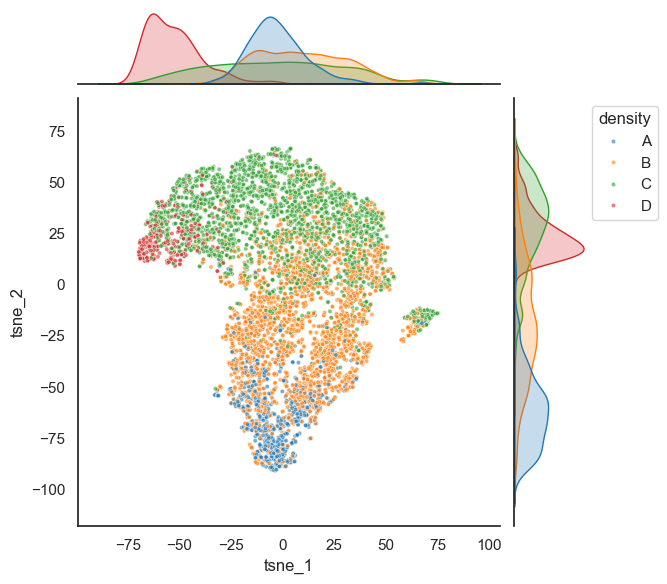

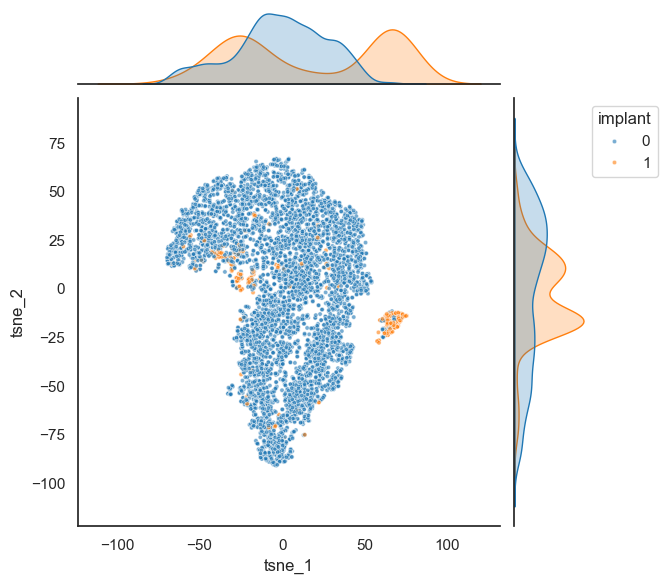

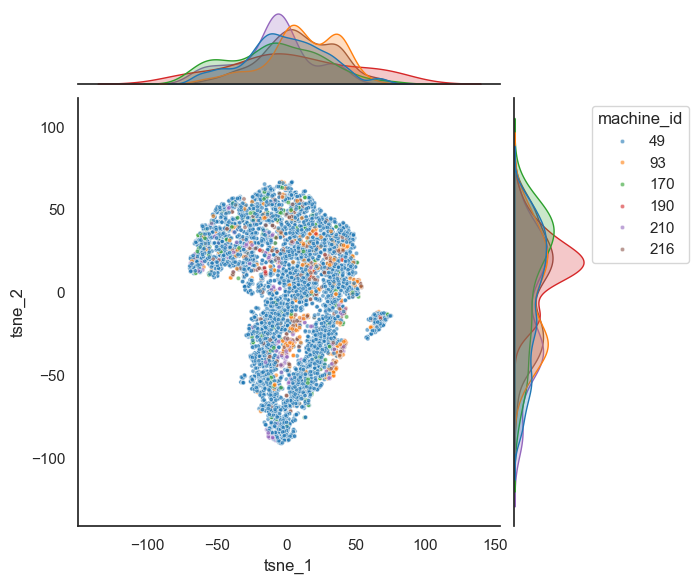

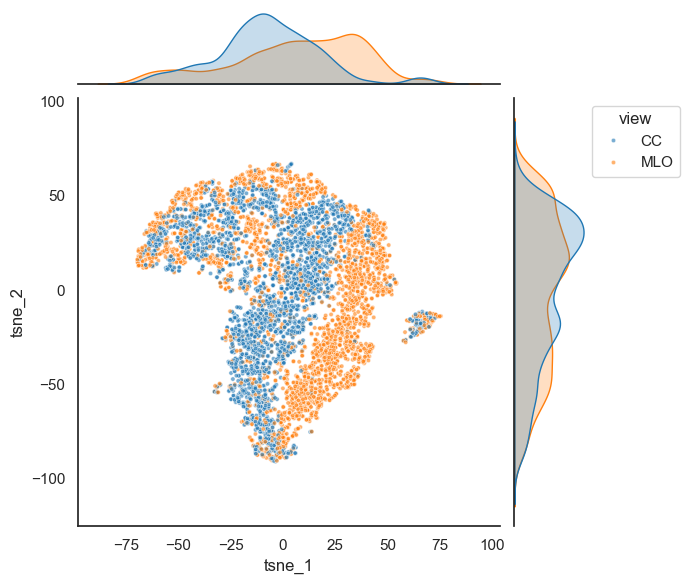

In [ ]:
# Feature-space plot considering t-SNE projections of embeddings
x = 'tsne_1'
y = 'tsne_2'
plot_joint(df, 'density', x, y, color_palette)
plot_joint(df, 'implant', x, y, color_palette)
plot_joint(df, 'machine_id', x, y, color_palette)
plot_joint(df, 'view', x, y, color_palette)

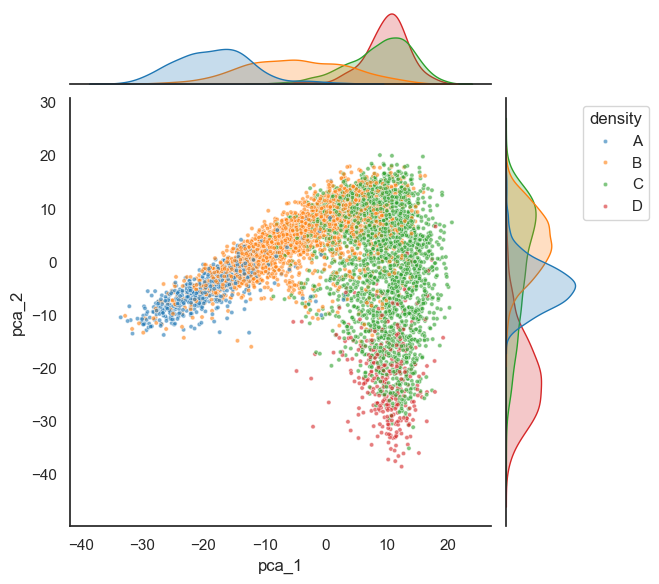

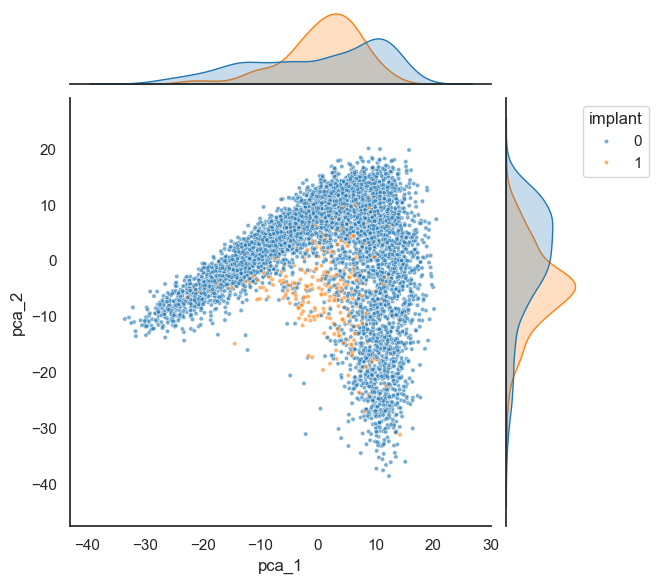

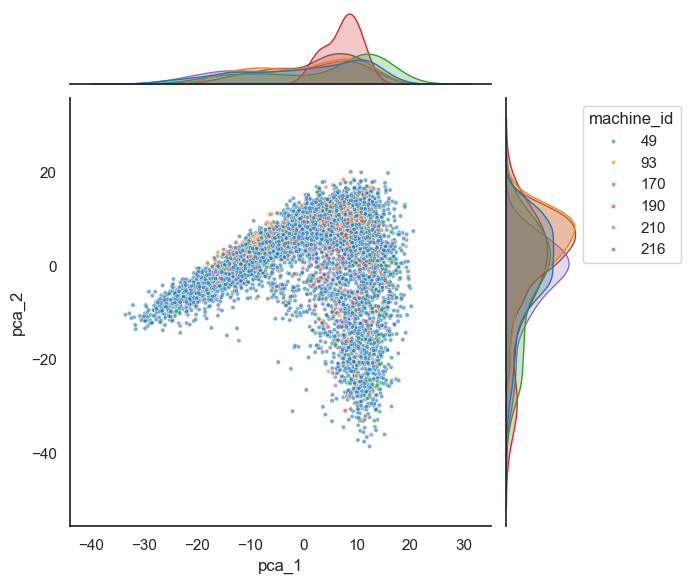

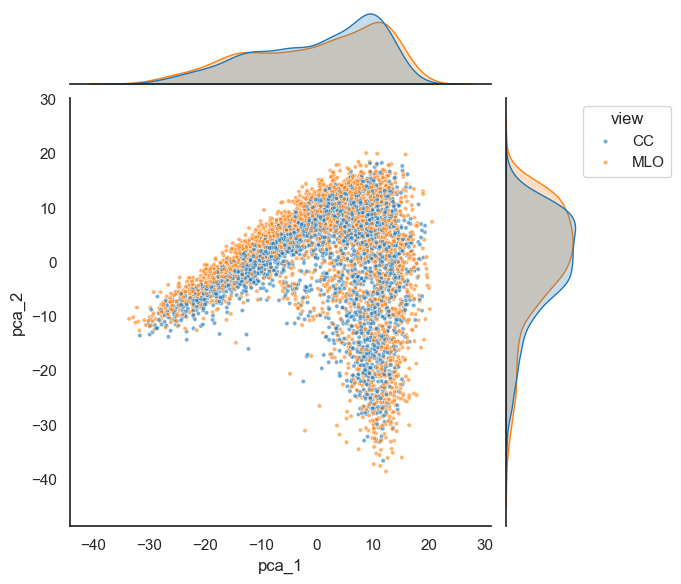

In [ ]:
# Feature-space plot considering PCA projections of embeddings
x = 'pca_1'
y = 'pca_2'
plot_joint(df, 'density', x, y, color_palette)
plot_joint(df, 'implant', x, y, color_palette)
plot_joint(df, 'machine_id', x, y, color_palette)
plot_joint(df, 'view', x, y, color_palette)

### Interactive visualisation

With the code below you can interactively explore the latent space to better understand how samples are distributed. You can modify the code to overlay different types of meta information.

In [19]:
df["image_path"] = [
    os.path.join("images", str(df.study_id.values[idx]), str(df.image_id.values[idx]) + ".png")
    for idx in range(len(df))
]

df['color_label'] = 0
df.loc[df['density'] == 'A', 'color_label'] = 0
df.loc[df['density'] == 'B', 'color_label'] = 1
df.loc[df['density'] == 'C', 'color_label'] = 2
df.loc[df['density'] == 'D', 'color_label'] = 3

In [20]:
def rgb_to_hex(rgb):
    return '#{:02x}{:02x}{:02x}'.format(rgb[0], rgb[1], rgb[2])

color = cm.tab10(np.linspace(0, 1, 10))
colorlist = [(np.array(mpl.colors.to_rgb(c))*255).astype(int).tolist() for c in color]*10

colors = [rgb_to_hex(colorlist[c]) for c in df.color_label.values]

In [21]:
def preprocess(image):
    # breast mask
    image_norm = image - np.min(image)
    image_norm = image_norm / np.max(image_norm)
    thresh = cv2.threshold(img_as_ubyte(image_norm), 5, 255, cv2.THRESH_BINARY)[1]

    # Connected components with stats.
    nb_components, output, stats, _ = cv2.connectedComponentsWithStats(thresh, connectivity=4)

    # Find the largest non background component.
    # Note: range() starts from 1 since 0 is the background label.
    max_label, _ = max(
        [(i, stats[i, cv2.CC_STAT_AREA]) for i in range(1, nb_components)],
        key=lambda x: x[1],
    )
    mask = output == max_label
    image_masked = image.copy()
    image_masked[mask == 0] = 0

    return image_masked

In [22]:
out = Output()
@out.capture(clear_output=True)
def handle_click(trace, points, state):
    sample = df.iloc[points.point_inds[0]]
    img_orig = imread(os.path.join(DATA_DIR, sample.image_path))
    img_proc = preprocess(img_orig)

    s = [6] * len(df)
    for i in points.point_inds:
        s[i] = 12
    with fig.batch_update():
        scatter.marker.size = s

    f, (ax1, ax2) = plt.subplots(1,2, figsize=(8,8))
    ax1.imshow(img_orig, cmap='gray')
    ax1.set_title('original')
    ax1.axis('off')
    ax2.imshow(img_proc, cmap='gray')
    ax2.set_title('processed')
    ax2.axis('off')
    plt.show(f)

fig = go.FigureWidget(px.scatter(df, x=x, y=y, template='simple_white', hover_data={'density': True, x:False, y:False}))
fig.update_layout(width=600, height=600)
scatter = fig.data[0]
scatter.on_click(handle_click)
scatter.marker.size = [6] * len(df)
scatter.marker.color = colors

HBox([fig, out])

    'data': [{'customdata': array([['C'],
                                   ['C…